# Time Split and Baseline Foorecasts

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Loading the engineered dataset
project_root = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)

input_path = (
    project_root
    / 'data'
    / 'processed'
    / 'ca1_model_features.parquet'
)

feature_df = pd.read_parquet(input_path)

feature_df['date'] = pd.to_datetime(feature_df['date'])

feature_df = feature_df.sort_values(['store_id', 'item_id', 'date']).reset_index(drop=True)

print(f'Rows: {len(feature_df):,}')
print(f'Items: {feature_df["item_id"].nunique():,}')
print(
    f'Date range: {feature_df["date"].min().date()} '
    f'to {feature_df["date"].max().date()}'
)

Rows: 166,886
Items: 108
Date range: 2011-02-26 to 2016-05-22


### Defining the chronological periods

In [4]:
all_dates = pd.DatetimeIndex(sorted(feature_df['date'].unique()))

# Defining the period splits
train_dates = all_dates[:-56]
validation_dates = all_dates[-56:-28]
test_dates = all_dates[-28:]

The final 56 unique dates are divided into: first 28 Days as validation, last 28 days as testing, and everything earlier as training.

In [5]:
# Checking the boundaries
split_summary = pd.DataFrame({
    'split': [
        'Training',
        'Validation',
        'Testing'
    ],
    'start_date': [
        train_dates.min(),
        validation_dates.min(),
        test_dates.min()
    ],
    'end_date': [
        train_dates.max(),
        validation_dates.max(),
        test_dates.max()
    ],
    'number_of_dates': [
        len(train_dates),
        len(validation_dates),
        len(test_dates)
    ]
})

split_summary

,split,start_date,end_date,number_of_dates
0,Training,2011-02-26,2016-03-27,1857
1,Validation,2016-03-28,2016-04-24,28
2,Testing,2016-04-25,2016-05-22,28


In [6]:
# verifying the order
assert train_dates.max() < validation_dates.min()
assert validation_dates.max() < test_dates.min()

assert len(validation_dates) == 28
assert len(test_dates) == 28

print('Chronological split verified.')

Chronological split verified.


### Labelling every observation

In [7]:
feature_df['data_split'] = 'training'

feature_df.loc[
    feature_df['date'].isin(validation_dates),
    'data_split'
] = 'validation'

feature_df.loc[
    feature_df['date'].isin(test_dates),
    'data_split'
] = 'testing'

In [8]:
# Inspecting results
feature_df.groupby(
    'data_split'
).agg(
    rows=('sales', 'size'),
    items=('item_id', 'nunique'),
    first_date=('date', 'min'),
    last_date=('date', 'max')
)

,rows,items,first_date,last_date
data_split,,,,
testing,3024,108,2016-04-25,2016-05-22
training,160838,108,2011-02-26,2016-03-27
validation,3024,108,2016-03-28,2016-04-24


The data was divided by unique dates rather than individual rows because every date contains observations for multiple products. Random splitting was not used because it would allow future observations to influence model development.

### Creating the recursive forecast function

In [10]:
def recursive_baseline(
    history,
    horizon,
    method
):
    values = list(
        np.asarray(history,
                   dtype=float)
    )

    if len(values) < 28:
        raise ValueError(
            'At least 28 historical observations '
            'are required.'
        )

    forecasts = []

    for _ in range(horizon):

        if method == 'previous_day':
            prediction = values[-1]

        elif method == 'seasonal_naive_7':
            prediction = values[-7]

        elif method == 'rolling_mean_28':
            prediction = np.mean(values[-28:])

        else:
            raise ValueError(
                f'Unknown method: {method}'
            )

        prediction = max(0, float(prediction))

        forecasts.append(prediction)

        # Later forecast steps use earlier predictions,
        # not actual future sales.
        values.append(prediction)

    return np.asarray(forecasts)

### Generating forecast for every items

In [11]:
series_keys = [
    'store_id',
    'item_id'
]

baseline_methods = [
    'previous_day',
    'seasonal_naive_7',
    'rolling_mean_28'
]

In [12]:
# prediction function
def build_baseline_predictions(data, forecast_dates):
    forecast_dates = pd.DatetimeIndex(forecast_dates)

    forecast_start = forecast_dates.min()
    horizon = len(forecast_dates)

    prediction_frames = []

    for series_values, group in data.groupby(
        series_keys,
        sort=False
    ):
        group = group.sort_values('date')

        history = group.loc[group['date'] < forecast_start,'sales'].to_numpy()

        actual = group.loc[
            group['date'].isin(forecast_dates),
            [
                'store_id',
                'item_id',
                'dept_id',
                'cat_id',
                'date',
                'sales'
            ]
        ].sort_values('date')

        if len(actual) != horizon:
            raise ValueError(
                f'{series_values} contains '
                f'{len(actual)} forecast rows; '
                f'expected {horizon}.'
            )

        for method in baseline_methods:
            forecasts = recursive_baseline(
                history=history,
                horizon=horizon,
                method=method
            )

            prediction_frame = actual.copy()

            prediction_frame['model'] = method

            prediction_frame['forecast'] = forecasts

            prediction_frames.append(prediction_frame)

    return pd.concat(prediction_frames, ignore_index=True)

Creating validation forecast

In [13]:
validation_predictions = (
    build_baseline_predictions(data=feature_df,
                               forecast_dates=validation_dates)
)

validation_predictions.head()

,store_id,item_id,dept_id,cat_id,date,sales,model,forecast
0,CA_1,FOODS_1_010,FOODS_1,FOODS,2016-03-28,0,previous_day,0.0
1,CA_1,FOODS_1_010,FOODS_1,FOODS,2016-03-29,0,previous_day,0.0
2,CA_1,FOODS_1_010,FOODS_1,FOODS,2016-03-30,0,previous_day,0.0
3,CA_1,FOODS_1_010,FOODS_1,FOODS,2016-03-31,0,previous_day,0.0
4,CA_1,FOODS_1_010,FOODS_1,FOODS,2016-04-01,0,previous_day,0.0


In [14]:
# Checking the size
expected_rows = (
    feature_df['item_id'].nunique()
    * 28
    * len(baseline_methods)
)

print(
    f'Prediction rows: '
    f'{len(validation_predictions):,}'
)

print(
    f'Expected rows: '
    f'{expected_rows:,}'
)

assert len(validation_predictions) == expected_rows

Prediction rows: 9,072
Expected rows: 9,072


### Evaluation function

In [15]:
def calculate_metrics(predictions):
    metric_rows = []

    for model_name, group in predictions.groupby(
        'model'
    ):
        actual = group['sales'].to_numpy(dtype=float)

        forecast = group['forecast'].to_numpy(dtype=float)

        errors = actual - forecast

        mae = np.mean(np.abs(errors))

        rmse = np.sqrt(np.mean(errors ** 2))

        wape_denominator = np.sum(np.abs(actual))

        wape = (
            np.sum(np.abs(errors))
            / wape_denominator
            if wape_denominator > 0
            else np.nan
        )

        metric_rows.append({
            'model': model_name,
            'MAE': mae,
            'RMSE': rmse,
            'WAPE': wape
        })

    return (
        pd.DataFrame(metric_rows)
        .sort_values('WAPE')
        .reset_index(drop=True)
    )

In [16]:
# Calculayte the results
validation_metrics = calculate_metrics(validation_predictions)

validation_metrics

,model,MAE,RMSE,WAPE
0,rolling_mean_28,1.169400,2.417961,0.746363
1,seasonal_naive_7,1.432540,3.151173,0.914310
2,previous_day,1.507937,3.461905,0.962431


In [17]:
# Plotting one representative product item
best_baseline = validation_metrics.loc[0, 'model'
]

sample_item = validation_predictions['item_id'].iloc[0]

sample_forecast = validation_predictions.loc[
    (validation_predictions['item_id'] == sample_item)
    & 
    (validation_predictions['model'] == best_baseline)].sort_values('date')

sample_history = feature_df.loc[
    (feature_df['item_id']  == sample_item)
    & 
    (feature_df['date'] < validation_dates.min()),
    ['date', 'sales']].tail(90)

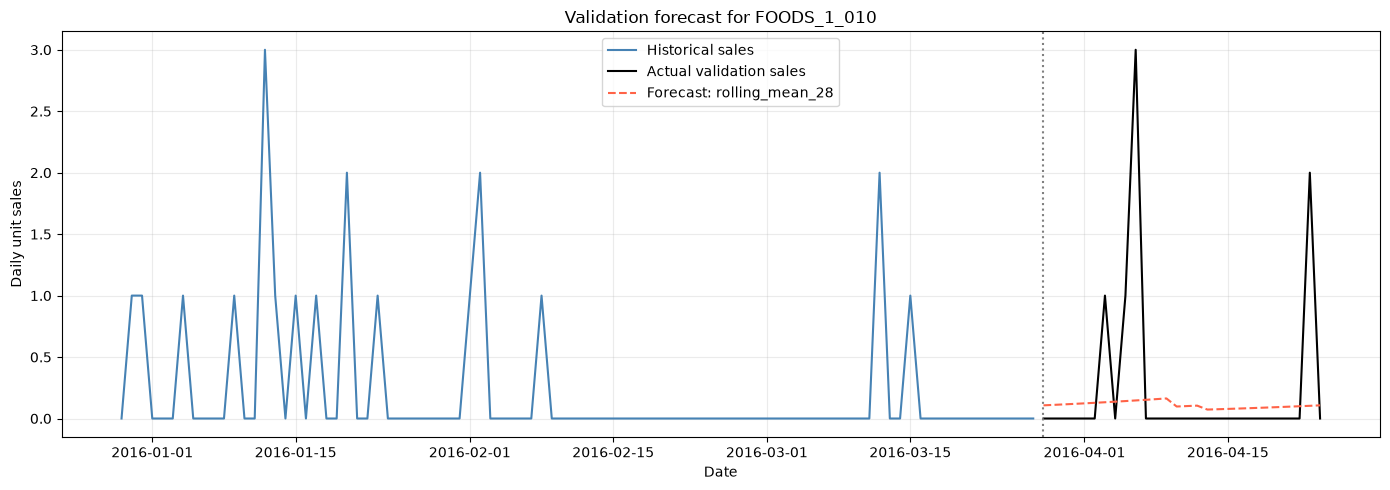

In [18]:
# Figure
plt.figure(figsize=(14, 5))

plt.plot(
    sample_history['date'],
    sample_history['sales'],
    label='Historical sales',
    color='steelblue'
)

plt.plot(
    sample_forecast['date'],
    sample_forecast['sales'],
    label='Actual validation sales',
    color='black'
)

plt.plot(
    sample_forecast['date'],
    sample_forecast['forecast'],
    label=f'Forecast: {best_baseline}',
    color='tomato',
    linestyle='--'
)

plt.axvline(
    validation_dates.min(),
    color='grey',
    linestyle=':'
)

plt.title(f'Validation forecast for {sample_item}')

plt.xlabel('Date')
plt.ylabel('Daily unit sales')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [19]:
# Saving
predictions_path = (
    project_root
    / 'data'
    / 'processed'
    / 'ca1_validation_baseline_predictions.parquet'
)

metrics_path = (
    project_root
    / 'reports'
    / 'baseline_validation_metrics.csv'
)

predictions_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

metrics_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

validation_predictions.to_parquet(
    predictions_path,
    index=False
)

validation_metrics.to_csv(
    metrics_path,
    index=False
)

print(f'Saved predictions: {predictions_path}')
print(f'Saved metrics: {metrics_path}')

Saved predictions: c:\Users\ryana\OneDrive - MMU\Documents\MSc Project\retail-demand-forecasting\data\processed\ca1_validation_baseline_predictions.parquet
Saved metrics: c:\Users\ryana\OneDrive - MMU\Documents\MSc Project\retail-demand-forecasting\reports\baseline_validation_metrics.csv
